In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import duckdb
import re, collections
import seaborn as sns

ACCENT, GREY, LIGHT = "#1F6F8B", "#9AA8B3", "#C9D6DC"
PAIR = [ACCENT, GREY]
sns.set_theme(style="whitegrid", context="notebook", rc={"figure.figsize": (8, 4.2),
              "axes.spines.top": False, "axes.spines.right": False})

def hbar(data, y, x, ax, fmt="{:,.0f}", color=ACCENT):
    """Horizontal seaborn bar chart in the frame's order, with value labels."""
    sns.barplot(data=data, y=y, x=x, ax=ax, color=color, orient="h", order=list(data[y]))
    ax.bar_label(ax.containers[0], labels=[fmt.format(v) for v in data[x]], padding=3, fontsize=8)
    ax.set_xlim(0, data[x].max() * 1.18)
    ax.set_ylabel("")

def paired_share(data, cat, cols, names, ax):
    """Two percentage columns side by side per category (e.g. % repos vs % files)."""
    long = data.melt(id_vars=cat, value_vars=cols, var_name="measure", value_name="pct")
    long["measure"] = long.measure.map(dict(zip(cols, names)))
    sns.barplot(data=long, x=cat, y="pct", hue="measure", palette=PAIR, ax=ax, order=list(data[cat]))
    for cont in ax.containers:
        ax.bar_label(cont, fmt="%.1f", fontsize=8)
    ax.set_ylabel("%"); ax.legend(title="")

from pathlib import Path

def _abs_parquet(rel):
    """Resolve a path relative to src/notebooks and return the absolute parquet path."""
    here = Path.cwd().resolve()
    data = None
    for candidate in (here, *here.parents):
        if (candidate / 'src' / 'data').is_dir() and (candidate / 'src' / 'notebooks').is_dir():
            data = candidate / 'src' / 'data'
            break
        if candidate.name == 'notebooks' and (candidate.parent / 'data').is_dir():
            data = (candidate.parent / 'data').resolve()
            break
    if data is None:
        raise FileNotFoundError(f'Could not locate src/data from {here}')
    path = (data / rel.removeprefix('../data/')).resolve()
    matches = list(path.parent.glob(path.name)) if '*' in path.name else ([path] if path.is_file() else [])
    if not matches:
        raise FileNotFoundError(path)
    return str(path)

repos_path = _abs_parquet('../data/gitskills_data/data/repos/*.parquet')
artifacts_path = _abs_parquet('../data/gitskills_data/data/artifacts/*.parquet')
artifact_siblings_path = _abs_parquet('../data/gitskills_data/data/artifact_siblings/*.parquet')
mining_runs_path = _abs_parquet('../data/gitskills_data/data/mining_runs/*.parquet')
skill_features_path = _abs_parquet('../data/generated_data/skill_features.parquet')
file_agents_path = _abs_parquet('../data/generated_data/file_agents.parquet')

con = duckdb.connect(database=':memory:')

## Copies and most-adopted skills

How often the same skill text is copied, and which skills appear in the most files, repositories, and owners. The sections below also separate in-repo mirroring from cross-owner reuse, and check whether location, scripts, front matter, or stars change that reuse rate.


#### Copies per content

In [2]:
copy_content_frequency = con.execute(f"""
    SELECT cp as number_of_copies, COUNT(*) as number_of_skills
    FROM (SELECT COUNT(*) AS cp
      FROM read_parquet('{artifacts_path}')
      GROUP BY file_sha)
    GROUP BY cp
    ORDER BY cp
""").df()
copy_content_frequency

,number_of_copies,number_of_skills
0,1,1489480
1,2,179980
2,3,74431
3,4,38678
4,5,22763
...,...,...
333,1074,1
334,1176,1
335,1245,1
336,1252,1


This means that there are 1,489,480 skills that have only 1 copy. There are 179,980 skills that have exactly 2 copies, and so on. The maximum number of copies for a single skill is 1,409.

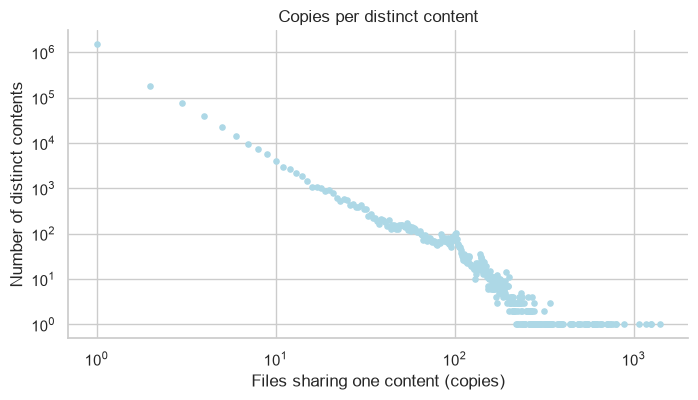

In [3]:
dist = copy_content_frequency
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(dist.number_of_copies, dist.number_of_skills, s=14, c="lightblue")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Files sharing one content (copies)"); ax.set_ylabel("Number of distinct contents")
ax.set_title("Copies per distinct content")
plt.show()
# dist.head(10).to_frame("contents")

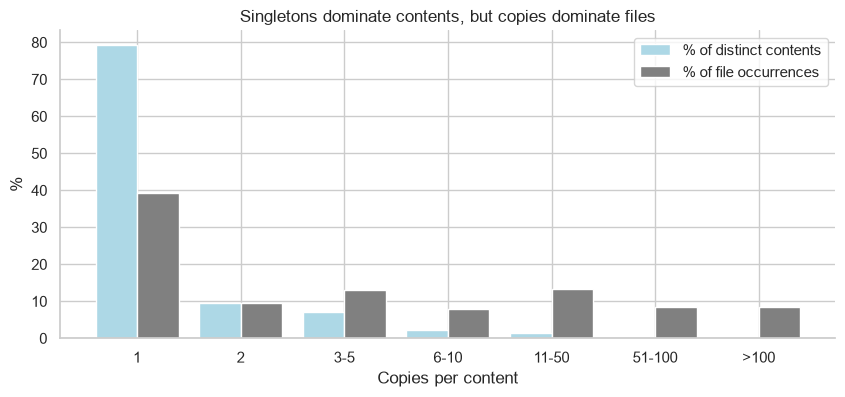

,distinct_skills,total_files,% distinct_skills,% total_files
copy_bucket,,,,
1,1489480,1489480,79.3,39.2
2,179980,359960,9.6,9.5
3-5,135872,491820,7.2,13.0
6-10,40914,303615,2.2,8.0
11-50,25140,510266,1.3,13.4
51-100,4492,322613,0.2,8.5
>100,2103,319363,0.1,8.4


In [4]:
file_frequency = con.execute(f"""
    select
        a.file_sha,
        count(*) as files
    FROM read_parquet('{artifacts_path}') a
    LEFT JOIN read_parquet('{repos_path}') r ON r.full_name = a.repo_full_name
    GROUP BY a.file_sha
""").df()

bins   = [0, 1, 2, 5, 10, 50, 100, np.inf]
labels = ["1", "2", "3-5", "6-10", "11-50", "51-100", ">100"]
file_frequency["copy_bucket"] = pd.cut(file_frequency.files, bins=bins, labels=labels)
bk = file_frequency.groupby("copy_bucket", observed=False).agg(distinct_skills=("file_sha", "size"), total_files=("files", "sum"))
bk["% distinct_skills"] = (100 * bk.distinct_skills / bk.distinct_skills.sum()).round(1)
bk["% total_files"]    = (100 * bk.total_files / bk.total_files.sum()).round(1)

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(bk)); w = .4
ax.bar(x - w/2, bk["% distinct_skills"], w, label="% of distinct contents", color="lightblue")
ax.bar(x + w/2, bk["% total_files"],    w, label="% of file occurrences", color="gray")
ax.set_xticks(x, bk.index); ax.set_xlabel("Copies per content"); ax.set_ylabel("%")
ax.set_title("Singletons dominate contents, but copies dominate files"); ax.legend()
plt.show()
bk

**Findings (full dataset, 1,877,981 distinct skills / 3,797,117 files)**
- Most skills are unique: 79.3% of distinct skills exist as a single file.
- Most files are shared: 60.8% of files belong to a skill with two or more
  copies; 50.5% of all files are redundant copies (matching the dataset paper).
- Duplication is concentrated: 31,735 skills with more than 10 copies
  (1.6% of distinct skills) account for 30.3% of all files; the 2,103 skills
  with more than 100 copies alone account for 8.4%.
- The sample overstates duplication (74.0% singletons vs 79.3% here) because
  it includes every copy of each selected skill; cite full-dataset figures.
  The last section turns 10 or more copies into the highly templated class
  used by the authorship label. That cutoff includes skills with exactly 10
  copies, so it is slightly larger than the "more than 10" count above.

In [5]:
file_frequency = con.execute(f"""
    SELECT MAX(a.name) AS name,
       COUNT(DISTINCT a.repo_full_name) AS repos,
       COUNT(DISTINCT r.owner)          AS owners,
       COUNT(*)                         AS files_per_skill
    FROM read_parquet('{artifacts_path}') a JOIN read_parquet('{repos_path}') r ON r.full_name = a.repo_full_name
    GROUP BY a.file_sha
    ORDER BY owners DESC
""").df()
file_frequency

,name,repos,owners,files_per_skill
0,frontend-design,951,897,1245
1,verification-before-completion,914,866,1252
2,webapp-testing,781,741,1176
3,systematic-debugging,656,629,885
4,pdf,661,612,1409
...,...,...,...,...
1877976,improve-codebase-architecture,1,1,1
1877977,penguiflow-memory,1,1,1
1877978,pdhd-tool-grounding,1,1,1
1877979,temporal-switch-neuromorphic-transfer,1,1,1


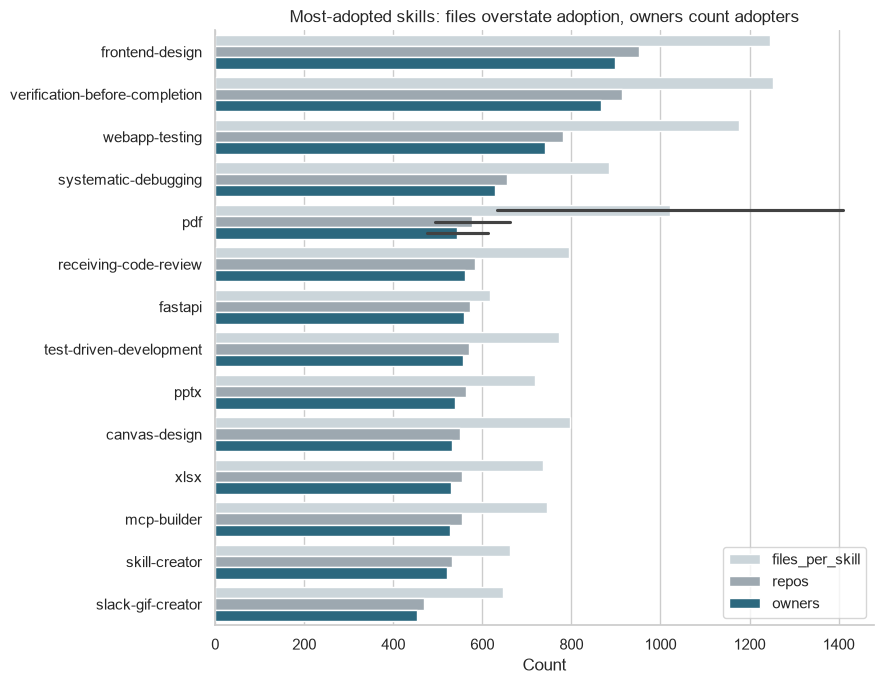

In [6]:
top = file_frequency.head(15).assign(name=lambda d: d.name.fillna("(no name)").str.slice(0, 36))
long = top.melt(id_vars="name", value_vars=["files_per_skill", "repos", "owners"],
                var_name="measure", value_name="count")
fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(data=long, y="name", x="count", hue="measure", orient="h",
            palette=[LIGHT, GREY, ACCENT], order=list(top.name), ax=ax)
ax.set_xlabel("Count"); ax.set_ylabel(""); ax.legend(title="", loc="lower right")
ax.set_title("Most-adopted skills: files overstate adoption, owners count adopters")
plt.tight_layout(); plt.show()

## Most-adopted skills: files per skill, repos and owners

**Findings (full dataset)**
- The most-adopted skills come from a few curated sources: 9 of the top 10 by
  distinct owners match Anthropic's official skills (`frontend-design`, `pdf`,
  `pptx`, `webapp-testing`, `canvas-design`) or the Superpowers collection
  (`verification-before-completion`, `systematic-debugging`,
  `test-driven-development`, `receiving-code-review`).
- `frontend-design` leads with 897 owners across 951 repos (1,245 files).
- Files overstate adoption unevenly: `pdf` has 2.3 files per owner, while
  `fastapi` has 1.1.
- Repos and owners nearly coincide for top skills (owners are 94–97% of repos),
  so in-repo mirroring, not multi-repo copying, drives the file inflation.
- That file inflation is about these most-adopted texts. The next section splits every duplicated content, where most are reused by two or more owners.
- Each row counts one exact text; versions of the same skill split across
  `file_sha` groups, so these figures are a lower bound on adoption.


#### Mirroring inside a repo vs reuse across repos

`files` counts every path, so a repository that places one skill in several folders inflates it. Repositories and owners measure real reuse. A content is duplicated when it has more than one file. It is mirrored inside a repository when it has more files than repositories.


In [7]:
reuse_where = con.execute(f"""
WITH g AS (
  SELECT COUNT(*) AS files,
         COUNT(DISTINCT a.repo_full_name) AS repos,
         COUNT(DISTINCT r.owner) AS owners
  FROM read_parquet('{artifacts_path}') a
  LEFT JOIN read_parquet('{repos_path}') r ON r.full_name = a.repo_full_name
  GROUP BY a.file_sha
)
SELECT COUNT(*) FILTER (WHERE files > 1) AS duplicated_contents,
       COUNT(*) FILTER (WHERE files > 1 AND repos = 1) AS within_one_repo,
       COUNT(*) FILTER (WHERE files > 1 AND repos > 1 AND owners = 1) AS multi_repo_one_owner,
       COUNT(*) FILTER (WHERE files > 1 AND owners > 1) AS multi_owner,
       COUNT(*) FILTER (WHERE files > 1 AND files > repos) AS in_repo_mirrors
FROM g
""").df()
reuse_where.T.rename(columns={0: "contents"})


,contents
duplicated_contents,388501
within_one_repo,82413
multi_repo_one_owner,75733
multi_owner,230355
in_repo_mirrors,193594


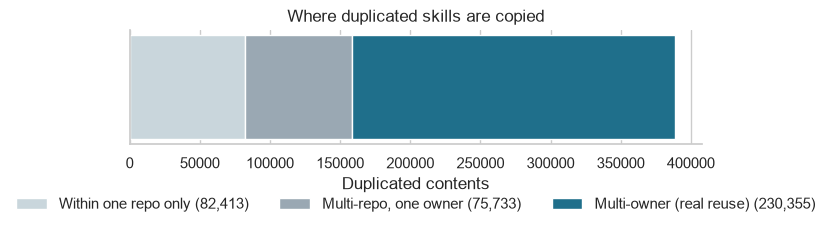

In [8]:
labels = ["Within one repo only", "Multi-repo, one owner", "Multi-owner (real reuse)"]
cols = ["within_one_repo", "multi_repo_one_owner", "multi_owner"]
vals = [int(reuse_where[c].iloc[0]) for c in cols]
fig, ax = plt.subplots(figsize=(8, 2.8))
left = 0
for lab, v, col in zip(labels, vals, [LIGHT, GREY, ACCENT]):
    ax.barh([0], [v], left=left, color=col, label=f"{lab} ({v:,})")
    left += v
ax.set_yticks([])
ax.set_xlabel("Duplicated contents")
ax.set_title("Where duplicated skills are copied")
ax.legend(loc="upper center", bbox_to_anchor=(.5, -0.35), ncol=3, frameon=False)
plt.tight_layout(); plt.show()


Of 388,501 contents that appear more than once, 82,413 (21.2%) stay inside a single repository and 75,733 (19.5%) span several repositories of one owner. The remaining 230,355 (59.3%) are reused by two or more owners. 193,594 duplicated contents have more file paths than repositories, so in-repo mirroring is common, but most duplicated contents are still cross-owner reuse. Counting files overstates adoption; counting owners does not erase it.


#### Skills where the file count overstates adoption

Contents with at least 20 files, ranked by files per owner. A high ratio means many paths and few adopters.


In [9]:
files_per_owner = con.execute(f"""
WITH g AS (
  SELECT coalesce(nullif(MAX(a.name), ''), '(no name)') AS name,
         COUNT(*) AS files,
         COUNT(DISTINCT a.repo_full_name) AS repos,
         COUNT(DISTINCT r.owner) AS owners
  FROM read_parquet('{artifacts_path}') a
  LEFT JOIN read_parquet('{repos_path}') r ON r.full_name = a.repo_full_name
  GROUP BY a.file_sha
)
SELECT name, files, repos, owners,
       ROUND(files * 1.0 / owners, 1) AS files_per_owner
FROM g
WHERE files >= 20 AND owners >= 1
ORDER BY files_per_owner DESC
LIMIT 10
""").df()
files_per_owner


,name,files,repos,owners,files_per_owner
0,planner,394,1,1,394.0
1,(no name),272,23,1,272.0
2,(no name),259,25,1,259.0
3,(no name),255,23,1,255.0
4,g-skl-platform-kiro,236,32,1,236.0
5,g-skl-github-pr,236,32,1,236.0
6,g-skl-platform-windsurf,235,33,1,235.0
7,(no name),234,21,1,234.0
8,(no name),231,27,1,231.0
9,(no name),229,25,1,229.0


The highest ratios are single-owner contents. `planner` is 394 files in 1 repository. Several unnamed contents and `g-skl-*` skills sit in a few dozen repositories of one owner. A ranking by files would treat these as widely adopted.


#### Does duplication depend on location, scripts, front matter, or popularity?

Rates are shares of distinct contents. Duplicated means more than one file. Reused means more than one owner. `max_stars` is the most-starred repository that holds the content, so a content with more copies has more chances to touch a starred repository.


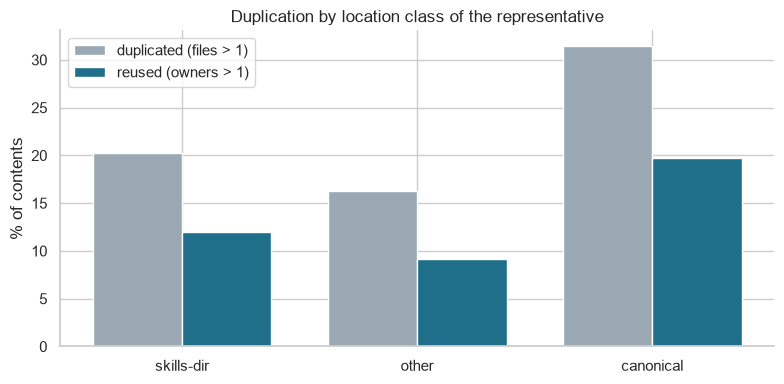

,rep_location,contents,dup_rate,reuse_rate,mean_owners
0,skills-dir,1037938,0.202,0.120,1.373
1,other,566322,0.163,0.092,1.166
2,canonical,273721,0.315,0.197,3.205


In [10]:
by_location = con.execute(f"""
WITH g AS (
  SELECT COUNT(*) AS files,
         COUNT(DISTINCT r.owner) AS owners,
         MAX(CASE WHEN a.dedup_primary = 1 THEN a.location_class END) AS rep_location
  FROM read_parquet('{artifacts_path}') a
  LEFT JOIN read_parquet('{repos_path}') r ON r.full_name = a.repo_full_name
  GROUP BY a.file_sha
)
SELECT coalesce(rep_location, '(none)') AS rep_location,
       COUNT(*) AS contents,
       ROUND(AVG((files > 1)::INT), 3) AS dup_rate,
       ROUND(AVG((owners > 1)::INT), 3) AS reuse_rate,
       ROUND(AVG(owners), 3) AS mean_owners
FROM g
GROUP BY 1
ORDER BY contents DESC
""").df()
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(by_location)); w = .38
ax.bar(x - w/2, 100 * by_location.dup_rate, w, label="duplicated (files > 1)", color=GREY)
ax.bar(x + w/2, 100 * by_location.reuse_rate, w, label="reused (owners > 1)", color=ACCENT)
ax.set_xticks(x, by_location.rep_location)
ax.set_ylabel("% of contents")
ax.legend()
ax.set_title("Duplication by location class of the representative")
plt.tight_layout(); plt.show()
by_location


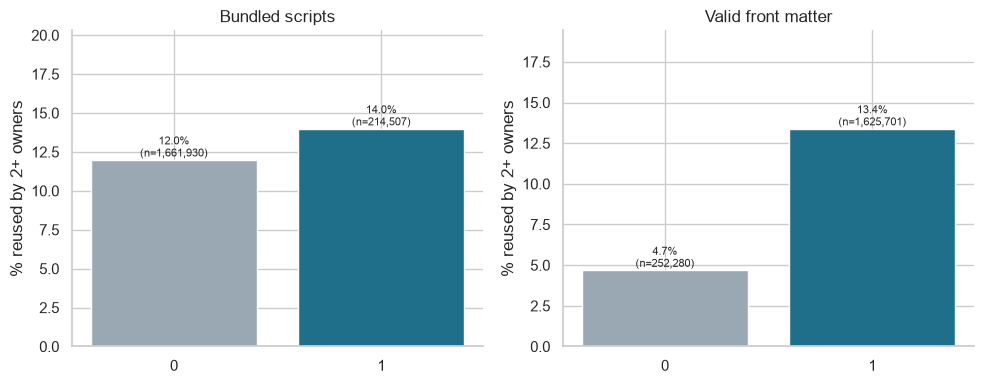

,flag,level,contents,reuse_pct
0,frontmatter_valid,0,252280,4.7
1,frontmatter_valid,1,1625701,13.4
2,has_scripts,0,1661930,12.0
3,has_scripts,1,214507,14.0
4,has_scripts,unknown,1544,15.5


In [11]:
flag_reuse = con.execute(f"""
WITH g AS (
  SELECT COUNT(DISTINCT r.owner) AS owners,
         MAX(CASE WHEN a.dedup_primary = 1 THEN a.has_scripts END) AS has_scripts,
         MAX(CASE WHEN a.dedup_primary = 1 THEN a.frontmatter_valid END) AS fm_valid
  FROM read_parquet('{artifacts_path}') a
  LEFT JOIN read_parquet('{repos_path}') r ON r.full_name = a.repo_full_name
  GROUP BY a.file_sha
)
SELECT 'has_scripts' AS flag,
       coalesce(CAST(has_scripts AS VARCHAR), 'unknown') AS level,
       COUNT(*) AS contents,
       ROUND(100.0 * AVG((owners > 1)::INT), 1) AS reuse_pct
FROM g GROUP BY 2
UNION ALL
SELECT 'frontmatter_valid',
       coalesce(CAST(fm_valid AS VARCHAR), 'unknown'),
       COUNT(*),
       ROUND(100.0 * AVG((owners > 1)::INT), 1)
FROM g GROUP BY 2
ORDER BY 1, 2
""").df()
plot_flags = flag_reuse[flag_reuse.level.isin(["0", "1"])]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, flag, title in [(axes[0], "has_scripts", "Bundled scripts"),
                        (axes[1], "frontmatter_valid", "Valid front matter")]:
    t = plot_flags[plot_flags.flag == flag]
    ax.bar(t.level, t.reuse_pct, color=[GREY, ACCENT][:len(t)])
    for i, (r, n) in enumerate(zip(t.reuse_pct, t.contents)):
        ax.text(i, r, f"{r:.1f}%\n(n={n:,.0f})", ha="center", va="bottom", fontsize=8)
    ax.set_title(title)
    ax.set_ylabel("% reused by 2+ owners")
    ax.set_ylim(0, t.reuse_pct.max() * 1.45)
plt.tight_layout(); plt.show()
flag_reuse


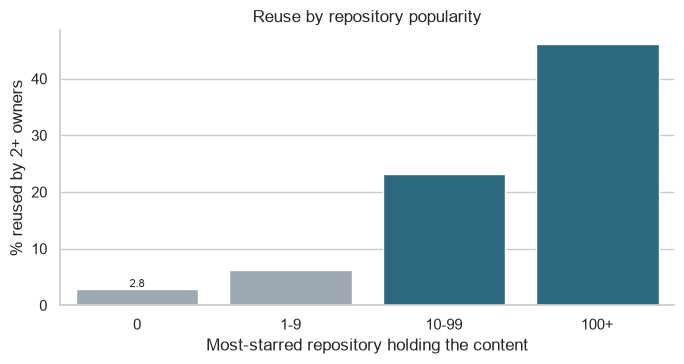

,stars,contents,reuse_pct
0,0,691173,2.8
1,1-9,638374,6.3
2,10-99,360185,23.2
3,100+,188249,46.2


In [12]:
by_stars = con.execute(f"""
WITH g AS (
  SELECT COUNT(DISTINCT r.owner) AS owners,
         MAX(coalesce(r.stars, 0)) AS max_stars
  FROM read_parquet('{artifacts_path}') a
  LEFT JOIN read_parquet('{repos_path}') r ON r.full_name = a.repo_full_name
  GROUP BY a.file_sha
)
SELECT CASE WHEN max_stars <= 0 THEN '0' WHEN max_stars < 10 THEN '1-9'
            WHEN max_stars < 100 THEN '10-99' ELSE '100+' END AS stars,
       COUNT(*) AS contents,
       ROUND(100.0 * AVG((owners > 1)::INT), 1) AS reuse_pct
FROM g
GROUP BY 1
ORDER BY MIN(max_stars)
""").df()
fig, ax = plt.subplots(figsize=(7, 3.8))
sns.barplot(data=by_stars, x="stars", y="reuse_pct", hue="stars",
            palette=[GREY, GREY, ACCENT, ACCENT], legend=False, ax=ax,
            order=list(by_stars.stars))
ax.bar_label(ax.containers[0], fmt="%.1f", fontsize=8)
ax.set_xlabel("Most-starred repository holding the content")
ax.set_ylabel("% reused by 2+ owners")
ax.set_title("Reuse by repository popularity")
plt.tight_layout(); plt.show()
by_stars


Canonical paths are copied more often than other locations: 31.5% of canonical contents are duplicated and 19.7% are reused by another owner (mean 3.2 owners). `skills-dir` is 20.2% duplicated and 12.0% reused; other paths are 16.3% and 9.2%.

Bundled scripts barely change reuse (14.0% with scripts, n=214,507, versus 12.0% without, n=1,661,930). Valid front matter does: 13.4% of contents with valid front matter are reused (n=1,625,701), against 4.7% when front matter is invalid (n=252,280).

Reuse rises with the most-starred host: 2.8% at 0 stars, 6.3% at 1–9, 23.2% at 10–99, and 46.2% at 100 or more. That gradient is partly mechanical, because a content stored in more repositories has more chances to touch a starred one.


## Highly templated class

The authorship label calls a skill highly templated when the same `file_sha` occurs in 10 or more files. The copy counts above describe the distribution. This section applies that cutoff as a class and checks whether those files are real reuse across owners or the same text repeated inside one repository.


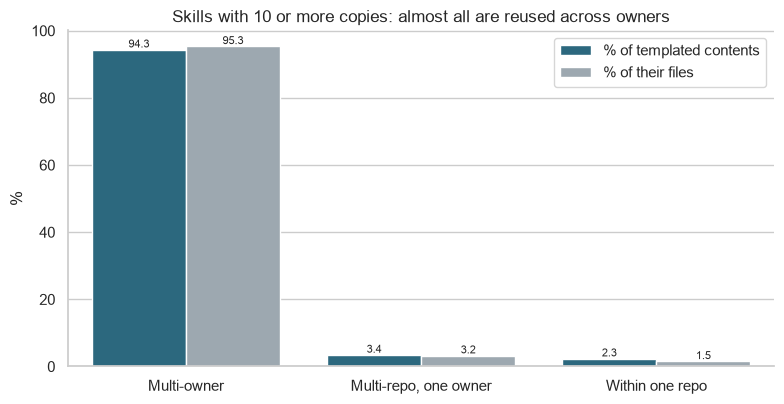

,where_copied,contents,files,pct_contents,pct_files
0,Multi-owner,33719,1135944.0,94.3,95.3
1,"Multi-repo, one owner",1230,38669.0,3.4,3.2
2,Within one repo,819,17959.0,2.3,1.5


In [13]:
TEMPLATE_MIN = 10  # same cutoff as the highly_templated label

templated_where = con.execute(f"""
WITH g AS (
  SELECT COUNT(*) AS files,
         COUNT(DISTINCT a.repo_full_name) AS repos,
         COUNT(DISTINCT r.owner) AS owners
  FROM read_parquet('{artifacts_path}') a
  LEFT JOIN read_parquet('{repos_path}') r ON r.full_name = a.repo_full_name
  GROUP BY a.file_sha
),
t AS (SELECT * FROM g WHERE files >= {TEMPLATE_MIN})
SELECT CASE
         WHEN repos = 1 THEN 'Within one repo'
         WHEN owners = 1 THEN 'Multi-repo, one owner'
         ELSE 'Multi-owner'
       END AS where_copied,
       COUNT(*) AS contents,
       SUM(files) AS files,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct_contents,
       ROUND(100.0 * SUM(files) / SUM(SUM(files)) OVER (), 1) AS pct_files
FROM t
GROUP BY 1
ORDER BY contents DESC
""").df()

order = ["Multi-owner", "Multi-repo, one owner", "Within one repo"]
templated_where["where_copied"] = pd.Categorical(templated_where.where_copied, order, ordered=True)
templated_where = templated_where.sort_values("where_copied").assign(where_copied=lambda d: d.where_copied.astype(str))

fig, ax = plt.subplots(figsize=(8, 4.2))
paired_share(templated_where, "where_copied", ["pct_contents", "pct_files"],
             ["% of templated contents", "% of their files"], ax)
ax.set_xlabel("")
ax.set_title(f"Skills with {TEMPLATE_MIN} or more copies: almost all are reused across owners")
plt.tight_layout(); plt.show()
templated_where


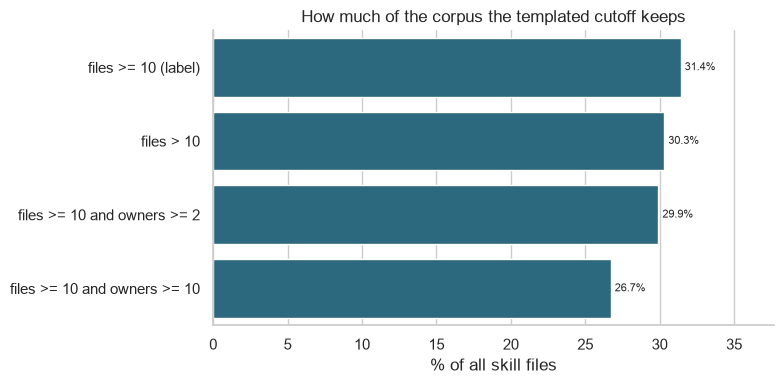

,rule,contents,files,pct_contents,pct_files
0,files >= 10 (label),35768,1192572.0,1.9,31.4
1,files > 10,31735,1152242.0,1.7,30.3
2,files >= 10 and owners >= 2,33719,1135944.0,1.8,29.9
3,files >= 10 and owners >= 10,24555,1014601.0,1.3,26.7


In [14]:
templated_sensitivity = con.execute(f"""
WITH g AS (
  SELECT COUNT(*) AS files,
         COUNT(DISTINCT r.owner) AS owners
  FROM read_parquet('{artifacts_path}') a
  LEFT JOIN read_parquet('{repos_path}') r ON r.full_name = a.repo_full_name
  GROUP BY a.file_sha
),
tot AS (SELECT COUNT(*) AS contents, SUM(files) AS files FROM g)
SELECT rule, contents, files,
       ROUND(100.0 * contents / (SELECT contents FROM tot), 1) AS pct_contents,
       ROUND(100.0 * files / (SELECT files FROM tot), 1) AS pct_files
FROM (
  SELECT 1 AS sort_key, 'files >= {TEMPLATE_MIN} (label)' AS rule,
         COUNT(*) AS contents, SUM(files) AS files FROM g WHERE files >= {TEMPLATE_MIN}
  UNION ALL
  SELECT 2, 'files > {TEMPLATE_MIN}', COUNT(*), SUM(files) FROM g WHERE files > {TEMPLATE_MIN}
  UNION ALL
  SELECT 3, 'files >= {TEMPLATE_MIN} and owners >= 2', COUNT(*), SUM(files)
  FROM g WHERE files >= {TEMPLATE_MIN} AND owners >= 2
  UNION ALL
  SELECT 4, 'files >= {TEMPLATE_MIN} and owners >= 10', COUNT(*), SUM(files)
  FROM g WHERE files >= {TEMPLATE_MIN} AND owners >= 10
)
ORDER BY sort_key
""").df()

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=templated_sensitivity, y="rule", x="pct_files", color=ACCENT,
            order=list(templated_sensitivity.rule), ax=ax)
ax.bar_label(ax.containers[0], labels=[f"{p:.1f}%" for p in templated_sensitivity.pct_files], padding=3, fontsize=8)
ax.set_xlim(0, templated_sensitivity.pct_files.max() * 1.2)
ax.set_xlabel("% of all skill files")
ax.set_ylabel("")
ax.set_title("How much of the corpus the templated cutoff keeps")
plt.tight_layout(); plt.show()
templated_sensitivity


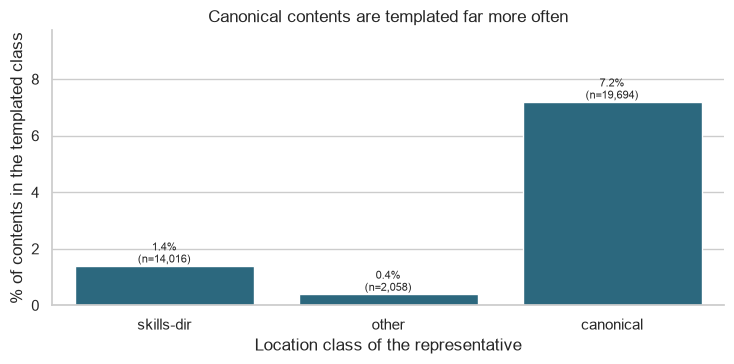

,rep_location,contents,templated,pct_templated
0,skills-dir,1037938,14016,1.4
1,other,566322,2058,0.4
2,canonical,273721,19694,7.2


In [15]:
templated_by_location = con.execute(f"""
WITH g AS (
  SELECT COUNT(*) AS files,
         MAX(CASE WHEN a.dedup_primary = 1 THEN a.location_class END) AS rep_location
  FROM read_parquet('{artifacts_path}') a
  GROUP BY a.file_sha
)
SELECT coalesce(rep_location, '(none)') AS rep_location,
       COUNT(*) AS contents,
       COUNT(*) FILTER (WHERE files >= {TEMPLATE_MIN}) AS templated,
       ROUND(100.0 * COUNT(*) FILTER (WHERE files >= {TEMPLATE_MIN}) / COUNT(*), 1) AS pct_templated
FROM g
GROUP BY 1
ORDER BY contents DESC
""").df()

fig, ax = plt.subplots(figsize=(7.5, 3.8))
sns.barplot(data=templated_by_location, x="rep_location", y="pct_templated", color=ACCENT,
            order=list(templated_by_location.rep_location), ax=ax)
ax.bar_label(ax.containers[0],
             labels=[f"{p:.1f}%\n(n={n:,})" for p, n in zip(templated_by_location.pct_templated, templated_by_location.templated)],
             fontsize=8)
ax.set_ylim(0, templated_by_location.pct_templated.max() * 1.35)
ax.set_xlabel("Location class of the representative")
ax.set_ylabel("% of contents in the templated class")
ax.set_title("Canonical contents are templated far more often")
plt.tight_layout(); plt.show()
templated_by_location


#### Findings

**The class is small in contents and large in files.** A skill is highly templated when its text occurs in 10 or more files, the same rule as the authorship label. That is 35,768 contents (1.9% of 1,877,981) and 1,192,572 files (31.4% of 3,797,117). The earlier "more than 10 copies" count, 31,735 contents and 30.3% of files, excludes skills with exactly 10 copies. Requiring 2 or more owners drops the class only to 33,719 contents and 29.9% of files. Requiring 10 or more owners leaves 24,555 contents and 26.7% of files. The cutoff moves the boundary; it does not decide whether the mass of files is shared.

**File count is not mostly in-repo mirroring, for this class.** Of the 35,768 templated contents, 33,719 (94.3%) are held by two or more owners, and those account for 95.3% of the class's files. Only 819 (2.3%) stay inside one repository, and 1,230 (3.4%) span several repositories of one owner. The median templated skill has 18 files, 14 repositories, and 13 owners. Many of those contents are also mirrored inside a repository, so a file count still overstates adopters, but dropping the single-owner contents removes 56,628 files, 4.7% of the class. The examples where one owner holds hundreds of paths, such as `planner`, sit in this small tail. They do not define the class.

**Canonical paths produce templates more often.** 7.2% of contents whose representative sits in a canonical agent folder are templated (19,694 of 273,721), against 1.4% in generic `skills/` directories (14,016 of 1,037,938) and 0.4% on other paths (2,058 of 566,322). More than half of the class (19,694 of 35,768) has a canonical representative, even though canonical contents are a minority of the dataset.
